In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Wczytanie danych (przykładowy zbiór AirPassengers)
train = pd.read_csv('AirPassengers.csv')
train2 = pd.read_csv('Electric_Production.csv')

# Konwersja kolumny czasu i ustawienie indeksu
train['Month'] = pd.to_datetime(train['Month'])
train.set_index('Month', inplace=True)

train2['DATE'] = pd.to_datetime(train2['DATE'])
train2.set_index('DATE', inplace=True)

# Wyświetlenie pierwszych wierszy
print(train.head())
print(train2.head())

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121
              Value
DATE               
1985-01-01  72.5052
1985-02-01  70.6720
1985-03-01  62.4502
1985-04-01  57.4714
1985-05-01  55.3151


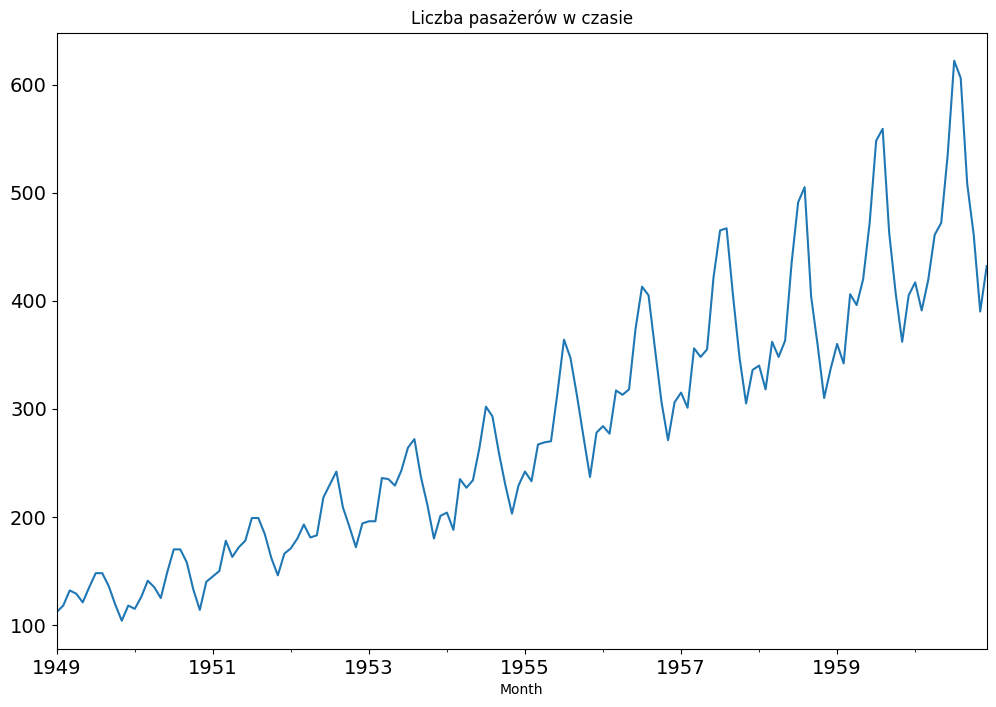

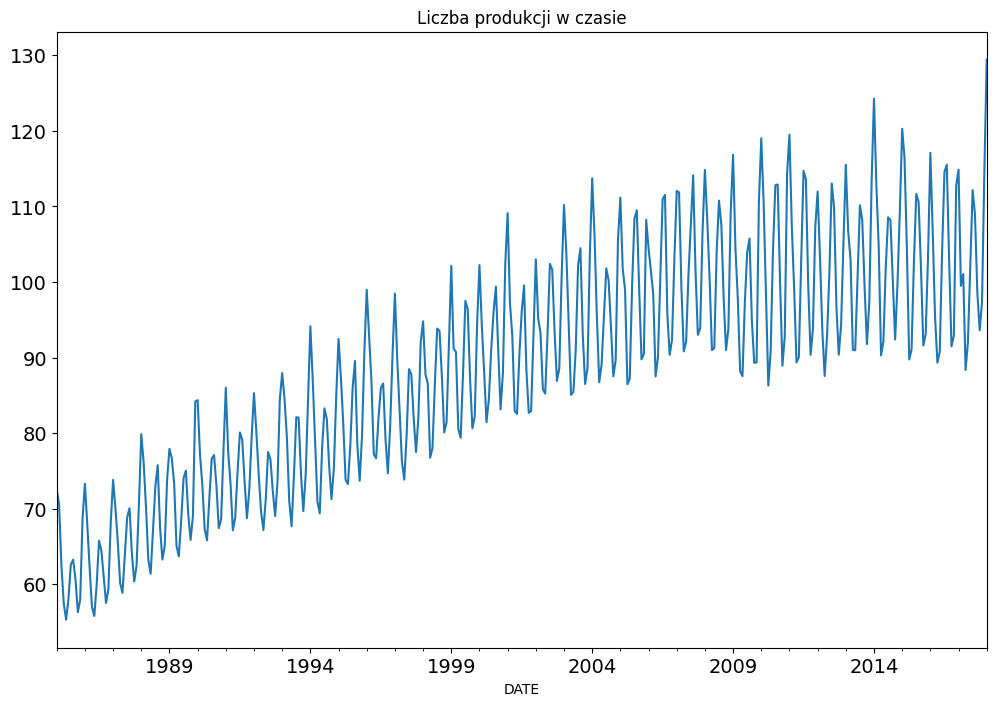

In [42]:
# Wykres szeregu czasowego
train['#Passengers'].plot(figsize=(12, 8), title='Liczba pasażerów w czasie', fontsize=14)
plt.show()
train2['Value'].plot(figsize=(12, 8), title='Liczba produkcji w czasie', fontsize=14)
plt.show()

In [43]:
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries):
    print('Wyniki testu Dickeya-Fullera:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Statystyka testowa', 'p-value', '#Lags Used', 'Liczba użytych obserwacji'])
    for key, value in dftest[4].items():
        dfoutput['Wartość krytyczna (%s)' % key] = value
    print(dfoutput)

# Wykonanie testu
adf_test(train['#Passengers'])
adf_test(train2['Value'])

Wyniki testu Dickeya-Fullera:
Statystyka testowa             0.815369
p-value                        0.991880
#Lags Used                    13.000000
Liczba użytych obserwacji    130.000000
Wartość krytyczna (1%)        -3.481682
Wartość krytyczna (5%)        -2.884042
Wartość krytyczna (10%)       -2.578770
dtype: float64
Wyniki testu Dickeya-Fullera:
Statystyka testowa            -2.256990
p-value                        0.186215
#Lags Used                    15.000000
Liczba użytych obserwacji    381.000000
Wartość krytyczna (1%)        -3.447631
Wartość krytyczna (5%)        -2.869156
Wartość krytyczna (10%)       -2.570827
dtype: float64


In [44]:
from statsmodels.tsa.stattools import kpss

def kpss_test(timeseries):
    print('Wyniki testu KPSS:')
    kpsstest = kpss(timeseries, regression='c', nlags="auto")
    kpss_output = pd.Series(kpsstest[0:3], index=['Statystyka testowa', 'p-value', 'Lags Used'])
    for key, value in kpsstest[3].items():
        kpss_output['Wartość krytyczna (%s)' % key] = value
    print(kpss_output)

# Wykonanie testu
kpss_test(train['#Passengers'])
kpss_test(train2['Value'])

Wyniki testu KPSS:
Statystyka testowa          1.651312
p-value                     0.010000
Lags Used                   8.000000
Wartość krytyczna (10%)     0.347000
Wartość krytyczna (5%)      0.463000
Wartość krytyczna (2.5%)    0.574000
Wartość krytyczna (1%)      0.739000
dtype: float64
Wyniki testu KPSS:
Statystyka testowa           3.531597
p-value                      0.010000
Lags Used                   10.000000
Wartość krytyczna (10%)      0.347000
Wartość krytyczna (5%)       0.463000
Wartość krytyczna (2.5%)     0.574000
Wartość krytyczna (1%)       0.739000
dtype: float64


/tmp/ipython-input-4004898328.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression='c', nlags="auto")
/tmp/ipython-input-4004898328.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression='c', nlags="auto")


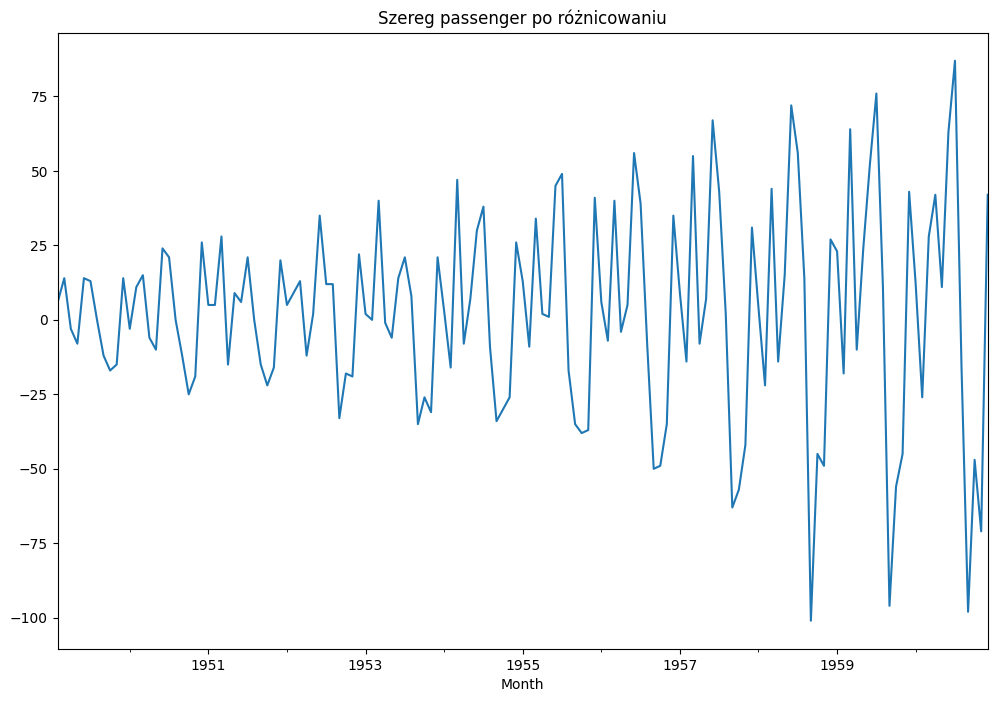

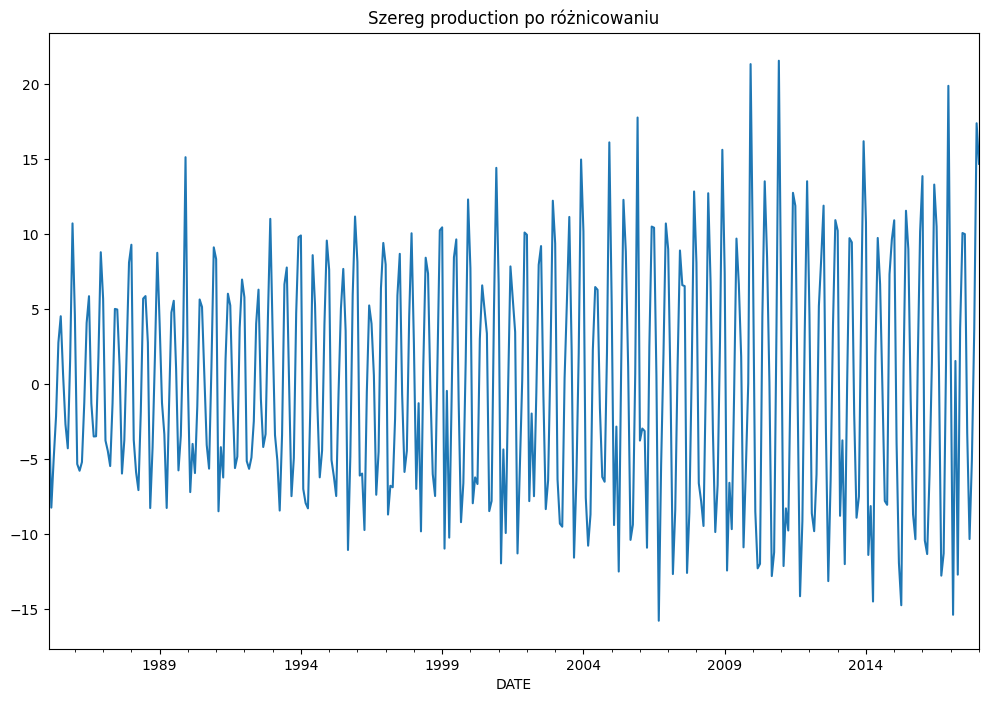

In [45]:
# Zastosowanie różnicowania w celu usunięcia trendu
train['#Passengers_diff'] = train['#Passengers'] - train['#Passengers'].shift(1)

# Wykres po różnicowaniu
train['#Passengers_diff'].dropna().plot(figsize=(12, 8), title='Szereg passenger po różnicowaniu passenger')
plt.show()

# Zastosowanie różnicowania w celu usunięcia trendu
train2['Value_diff'] = train2['Value'] - train2['Value'].shift(1)

# Wykres po różnicowaniu
train2['Value_diff'].dropna().plot(figsize=(12, 8), title='Szereg production po różnicowaniu production')
plt.show()

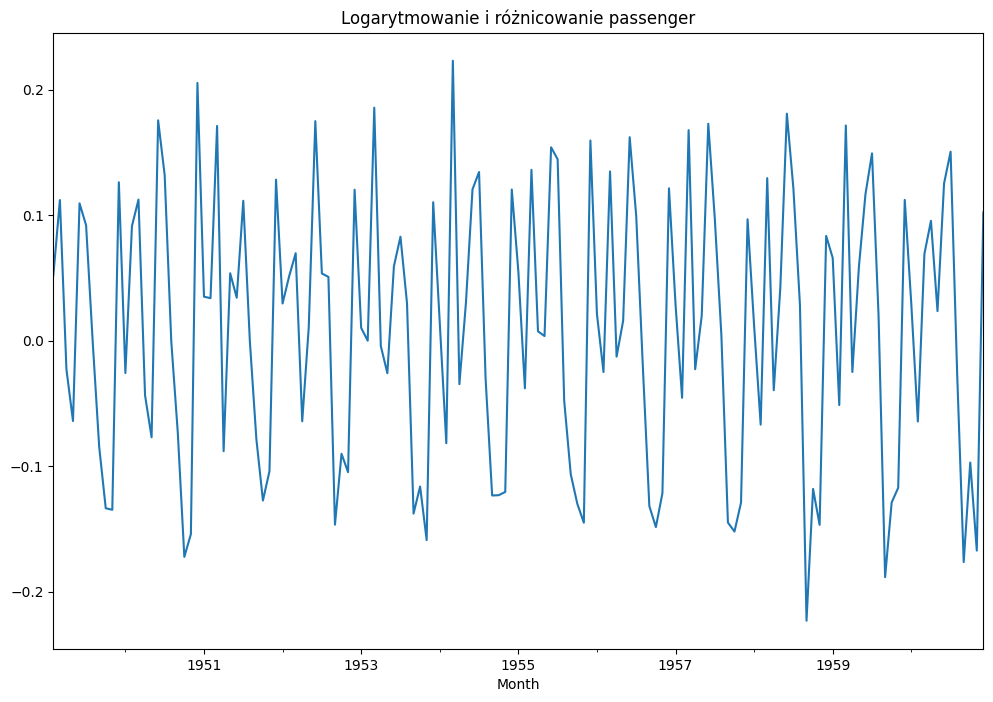

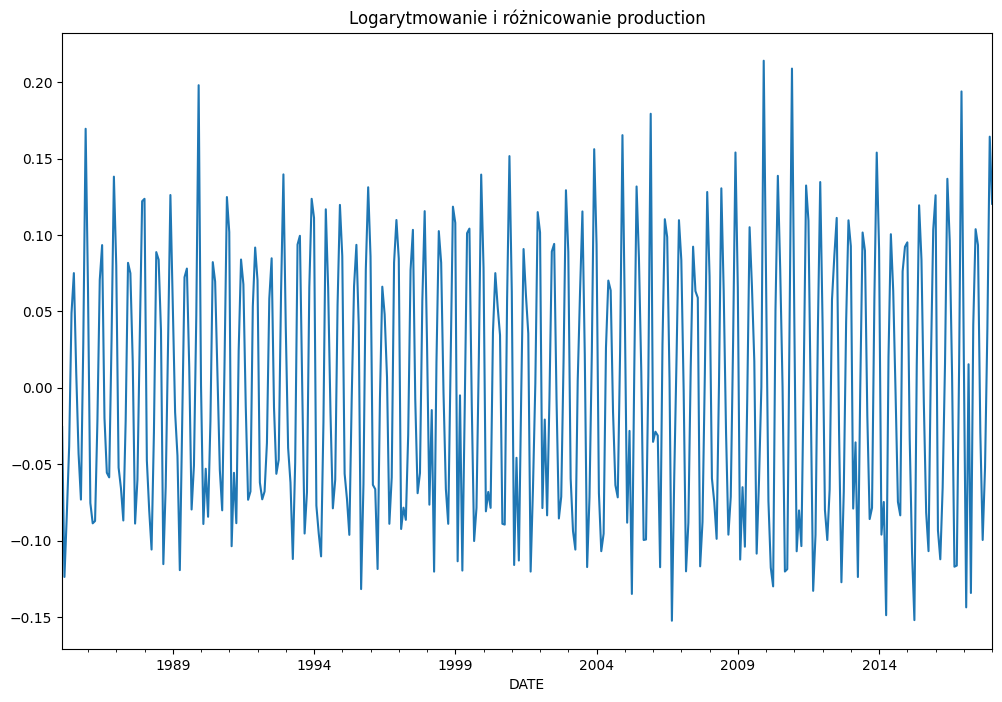

In [46]:
# Różnicowanie sezonowe (np. co 12 miesięcy)
train['#Passengers_seasonal_diff'] = train['#Passengers'] - train['#Passengers'].shift(12)

# Transformacja logarytmiczna w celu stabilizacji wariancji
train['#Passengers_log'] = np.log(train['#Passengers'])
train['#Passengers_log_diff'] = train['#Passengers_log'] - train['#Passengers_log'].shift(1)

# Wykres po transformacji i różnicowaniu
train['#Passengers_log_diff'].dropna().plot(figsize=(12, 8), title='Logarytmowanie i różnicowanie passenger')
plt.show()

# Różnicowanie sezonowe (np. co 12 miesięcy)
train2['Value_seasonal_diff'] = train2['Value'] - train2['Value'].shift(12)

# Transformacja logarytmiczna w celu stabilizacji wariancji
train2['Value_log'] = np.log(train2['Value'])
train2['Value_log_diff'] = train2['Value_log'] - train2['Value_log'].shift(1)

# Wykres po transformacji i różnicowaniu
train2['Value_log_diff'].dropna().plot(figsize=(12, 8), title='Logarytmowanie i różnicowanie production')
plt.show()